Exercise 4: NumPy Array Questions

In [1]:
import numpy as np

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
matrix = np.ones((5, 5))
matrix[1:4, 1:4] = 0
print(matrix)

# Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)
# Normalize each column to have mean=0 and std=1
normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print("\nColumn means: ")
print(normalized_data.mean(axis=0))

print("\nColumn standard deviations: ")
print(normalized_data.std(axis=0))

# Task 3: Implement linear regression solution using normal equation
# Given X (features) and y (target), compute theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50) * 0.1

# Calculate theta_hat using the normal equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
# Print the estimated coefficients and compare with true_theta
print("\nEstimated coefficients:")
print(theta_hat)

print("\nTrue coefficients:")
print(true_theta)

print("\nDifference: ")
print(theta_hat - true_theta)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Column means: 
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]

Column standard deviations: 
[1. 1. 1.]

Estimated coefficients:
[ 2.51723721 -1.19783796  3.72399266]

True coefficients:
[ 2.5 -1.2  3.7]

Difference: 
[0.01723721 0.00216204 0.02399266]


Exercise 5: Pandas Data Analysis

In [3]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40),
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), "exam_score"] = np.nan
df.loc[np.random.choice(n_students, 5), "hours_studied"] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)

# Display basic information about the dataset
print("===DATASET INFO===")
print(df.info())

print("===DESCRIPTIVE STATISTICS===")
print(df.describe())

# Identify and count missing values
print("===MISSING VALUES===")
print(df.isnull().sum())

# Fill missing exam_score with the mean score for the student's major
df["exam_score"] = df["exam_score"].fillna(
    df.groupby("major")["exam_score"].transform("mean")
)

# Fill missing hours_studied with the median for the student's year
df["hours_studied"] = df["hours_studied"].fillna(
    df.groupby("year")["hours_studied"].transform("median")
)

print("===MISSING VALUES AFTER CLEANING===")
print(df.isnull().sum())

# Task 2: Analysis

# Calculate and display the average exam_score by major
print("===AVERAGE EXAM SCORE BY MAJPR===")
avg_scores = df.groupby("major")["exam_score"].mean()
print(avg_scores)

# Find the major with the highest average exam_score
best_major = avg_scores.idxmax()
best_score = avg_scores.max()

print(f"Major with highest average score: {best_major}")
print(f"Average score: {best_score:.2f}")

# Calculate the correlation between hours_studied and exam_score
correlation = df["hours_studied"].corr(df["exam_score"])

print("===CORRELATION===")
print(f"Hours Studied vs Exam Score: {correlation:.4f}")

# Create a new column 'performance' with categories:
# 'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
df["performance"] = pd.cut(
    df["exam_score"],
    bins=[0, 70, 80, 90, 100],
    labels=["Needs Improvement", "Average", "Good", "Excellent"],
    include_lowest=True,
)

print("===PERFORMANCE DISTRIBUTION===")
print(df["performance"].value_counts())

# Task 3: Advanced Analysis
# For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
print("===MAJOR/YEAR ANALYSIS===")

major_year_stats = df.groupby(["major", "year"]).agg(
    num_students=("student_id", "count"),
    avg_exam_score=("exam_score", "mean"),
    avg_hours_studied=("hours_studied", "mean"),
)

print(major_year_stats)

# Identify top 5 students based on exam_score (handle ties appropriately)
print("===TOP STUDENTS===")

fifth_score = df["exam_score"].nlargest(5).min()

top_students = df[df["exam_score"] >= fifth_score].sort_values(
    "exam_score", ascending=False
)

# Create a pivot table showing average exam_score by major (rows) and year (columns)
print("===PIVOT TABLE===")
pivot = pd.pivot_table(
    df, values="exam_score", index="major", columns="year", aggfunc="mean"
)

print(pivot)


===DATASET INFO===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None
===DESCRIPTIVE STATISTICS===
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.0

Exercise 6: Data Visualization

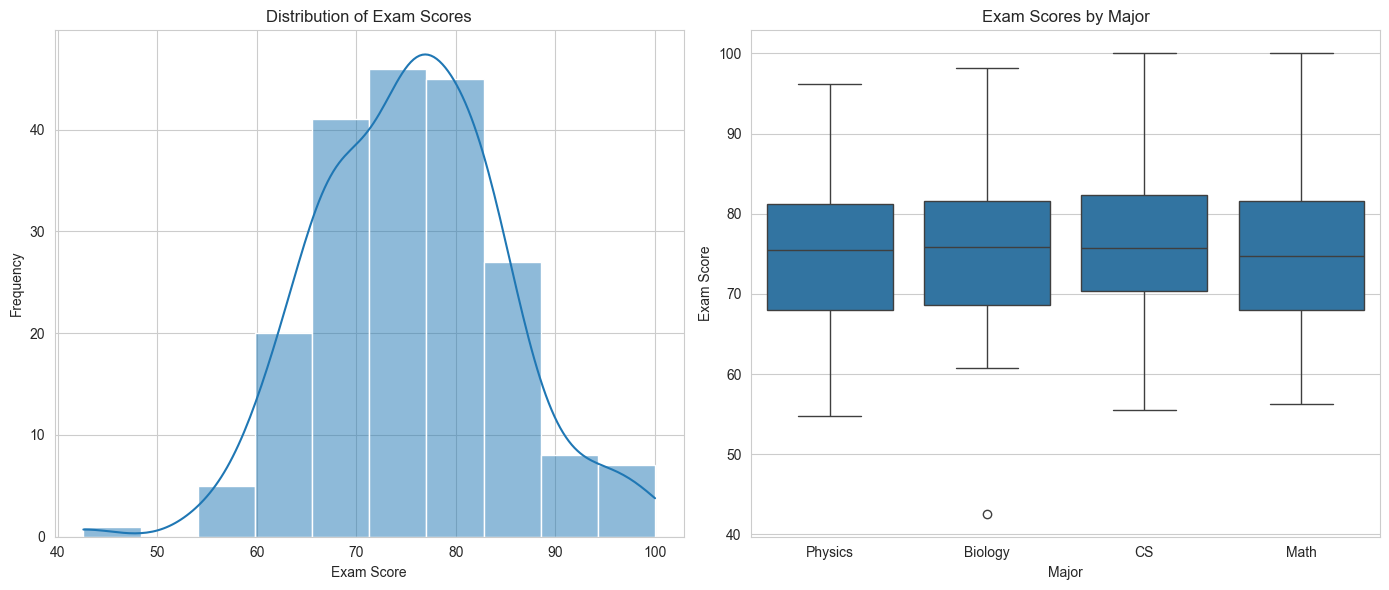

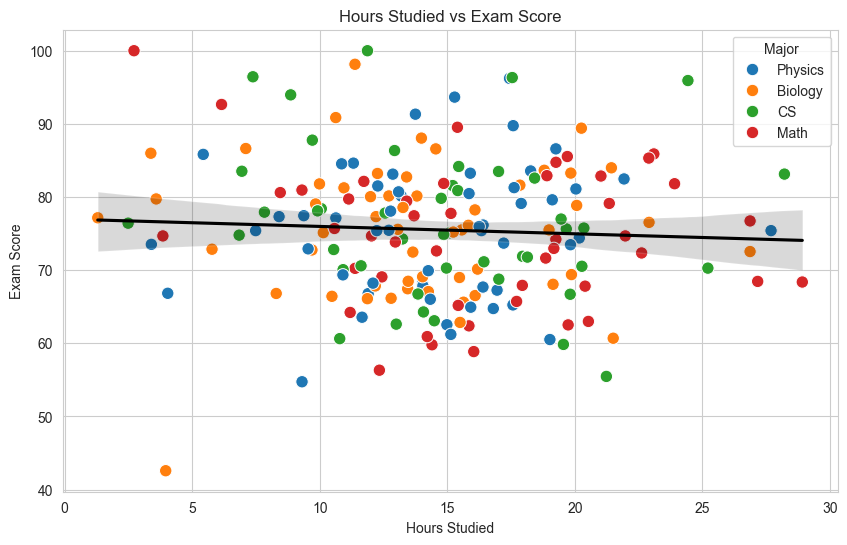

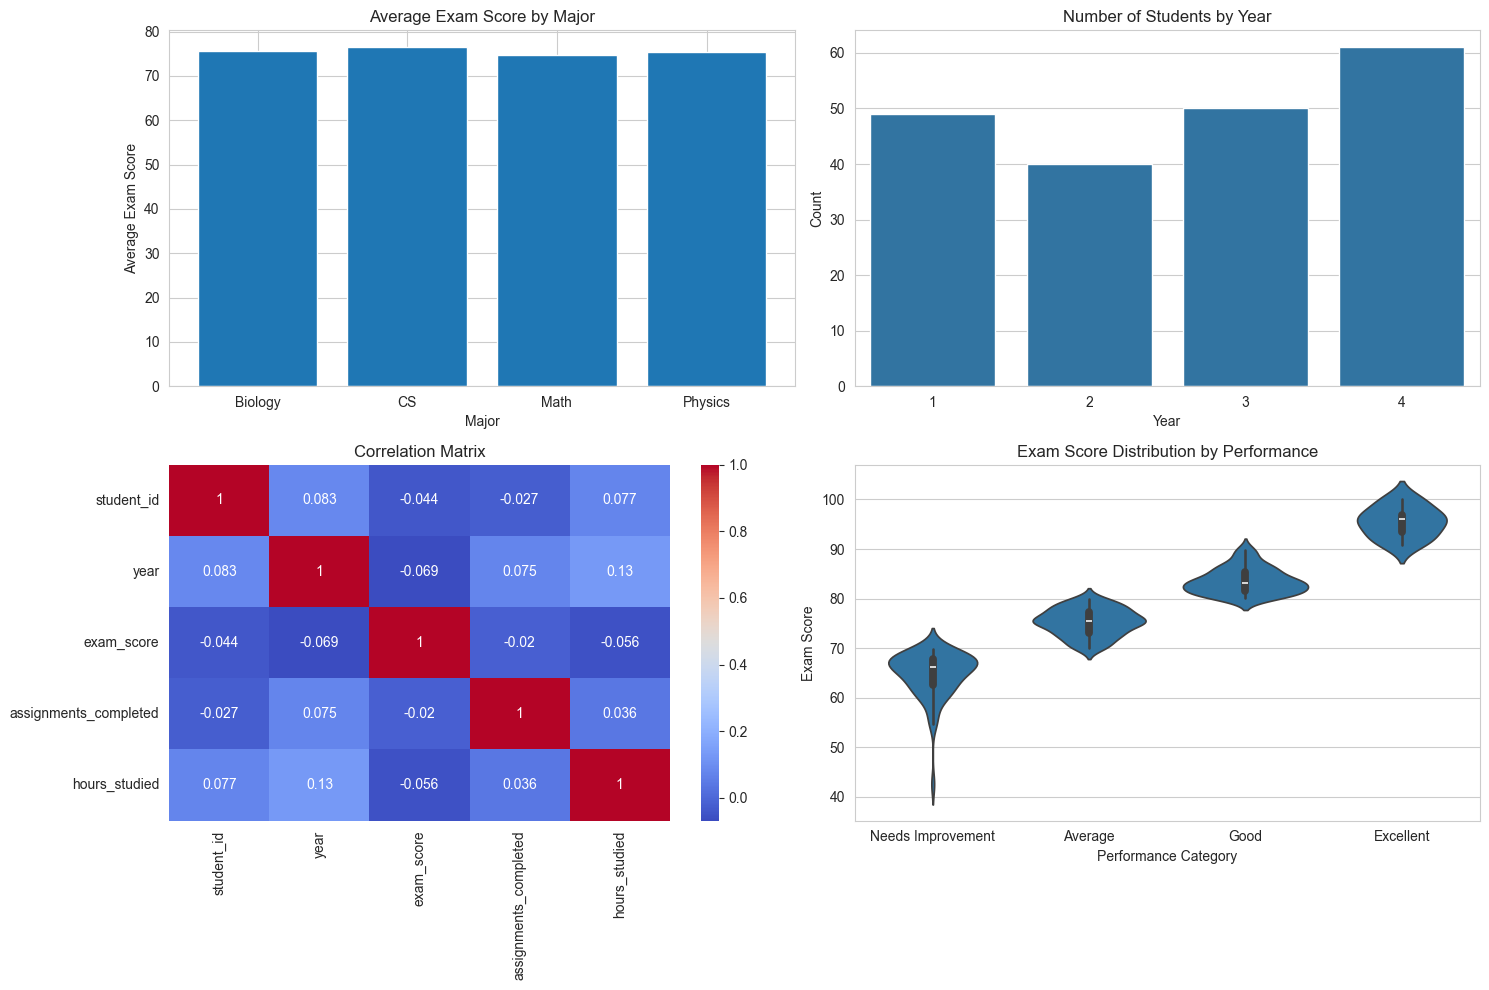

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using the df from Exercise 5

# Task 1: Distribution Visualization
sns.set_style("whitegrid")

# A figure with 2 subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Left: Histogram of exam scores with KDE overlay
sns.histplot(data=df, x="exam_score", kde=True, bins=10, ax=ax[0])

# With appropriate titles, labels, and styling
ax[0].set_title("Distribution of Exam Scores")
ax[0].set_xlabel("Exam Score")
ax[0].set_ylabel("Frequency")

# Right: Box plot of exam scores by major
sns.boxplot(data=df, x="major", y="exam_score", ax=ax[1])

# With appropriate titles, labels, and styling
ax[1].set_title("Exam Scores by Major")
ax[1].set_xlabel("Major")
ax[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization
plt.figure(figsize=(10, 6))

# A scatter plot of hours_studied vs exam_score & color points by major
sns.scatterplot(data=df, x="hours_studied", y="exam_score", hue="major", s=80)

# Adding a regression line
sns.regplot(data=df, x="hours_studied", y="exam_score", scatter=False, color="black")

# Appropriate legends, titles, and axis labels
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.show()

# Task 3: Advanced Dashboard
# Creating 'performance' category column
df["performance"] = pd.cut(
    df["exam_score"],
    bins=[0, 70, 80, 90, 100],
    labels=["Needs Improvement", "Average", "Good", "Excellent"],
)

# A 2x2 subplot figure:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Bar chart: Average exam score by major
avg_scores = df.groupby("major")["exam_score"].mean()

ax[0, 0].bar(avg_scores.index, avg_scores.values)

ax[0, 0].set_title("Average Exam Score by Major")
ax[0, 0].set_xlabel("Major")
ax[0, 0].set_ylabel("Average Exam Score")

# Count plot: Number of students by year
sns.countplot(data=df, x="year", ax=ax[0, 1])

ax[0, 1].set_title("Number of Students by Year")
ax[0, 1].set_xlabel("Year")
ax[0, 1].set_ylabel("Count")

# Heat map: Correlation matrix of numerical columns
numerical_cols = df.select_dtypes(include=["number"])

correlation = numerical_cols.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", ax=ax[1, 0])

ax[1, 0].set_title("Correlation Matrix")

# Violin plot: Exam score distribution by performance category
sns.violinplot(data=df, x="performance", y="exam_score", ax=ax[1, 1])

ax[1, 1].set_title("Exam Score Distribution by Performance")
ax[1, 1].set_xlabel("Performance Category")
ax[1, 1].set_ylabel("Exam Score")

# Adjusting layout, adding titles, and ensuring readability
plt.tight_layout()
plt.show()

Exercise 7: Integration Challenge

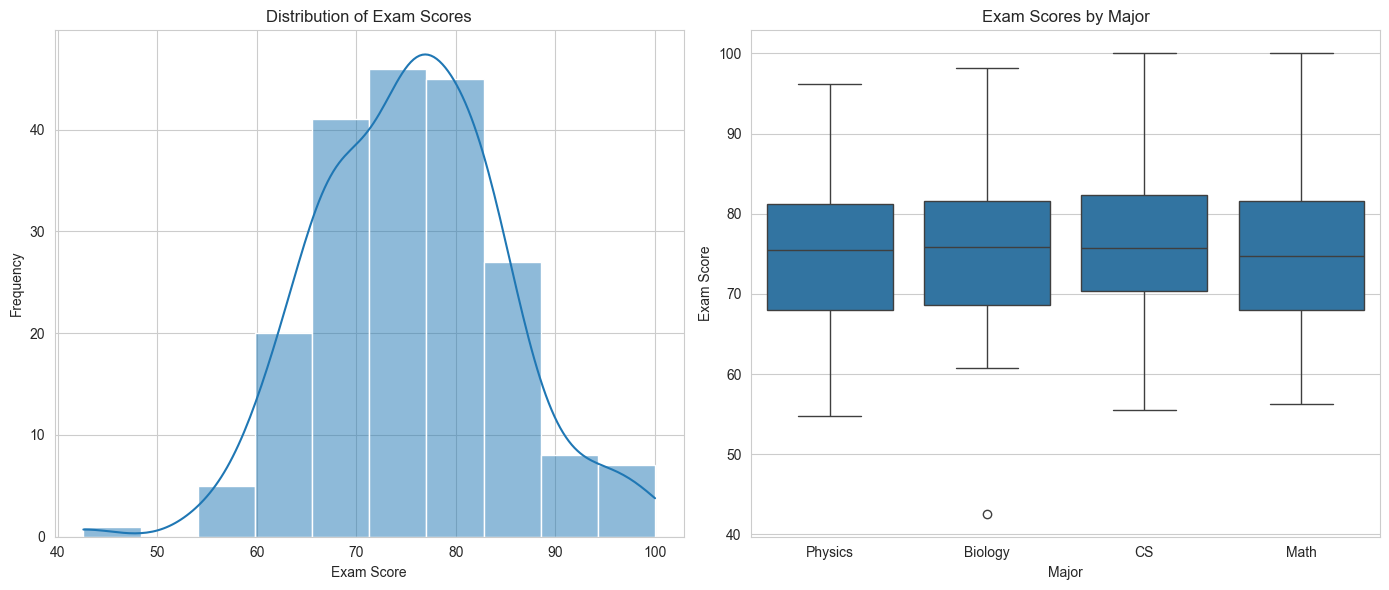

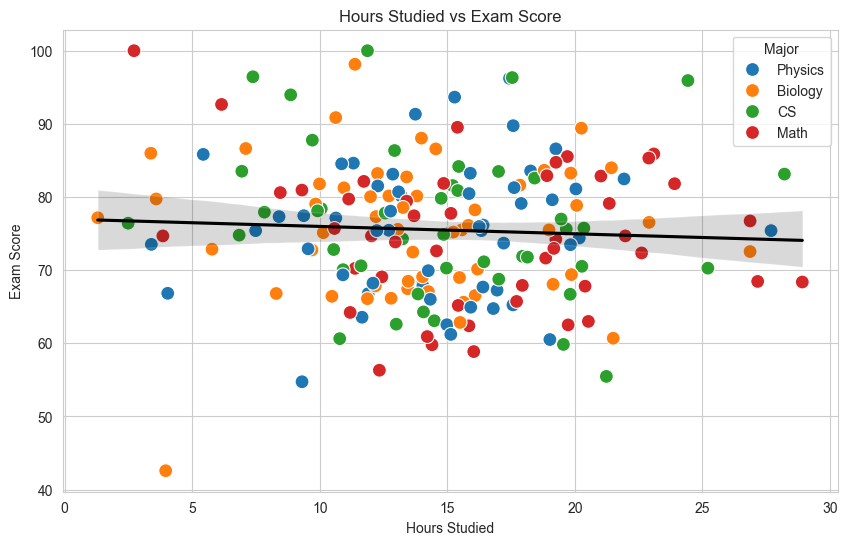

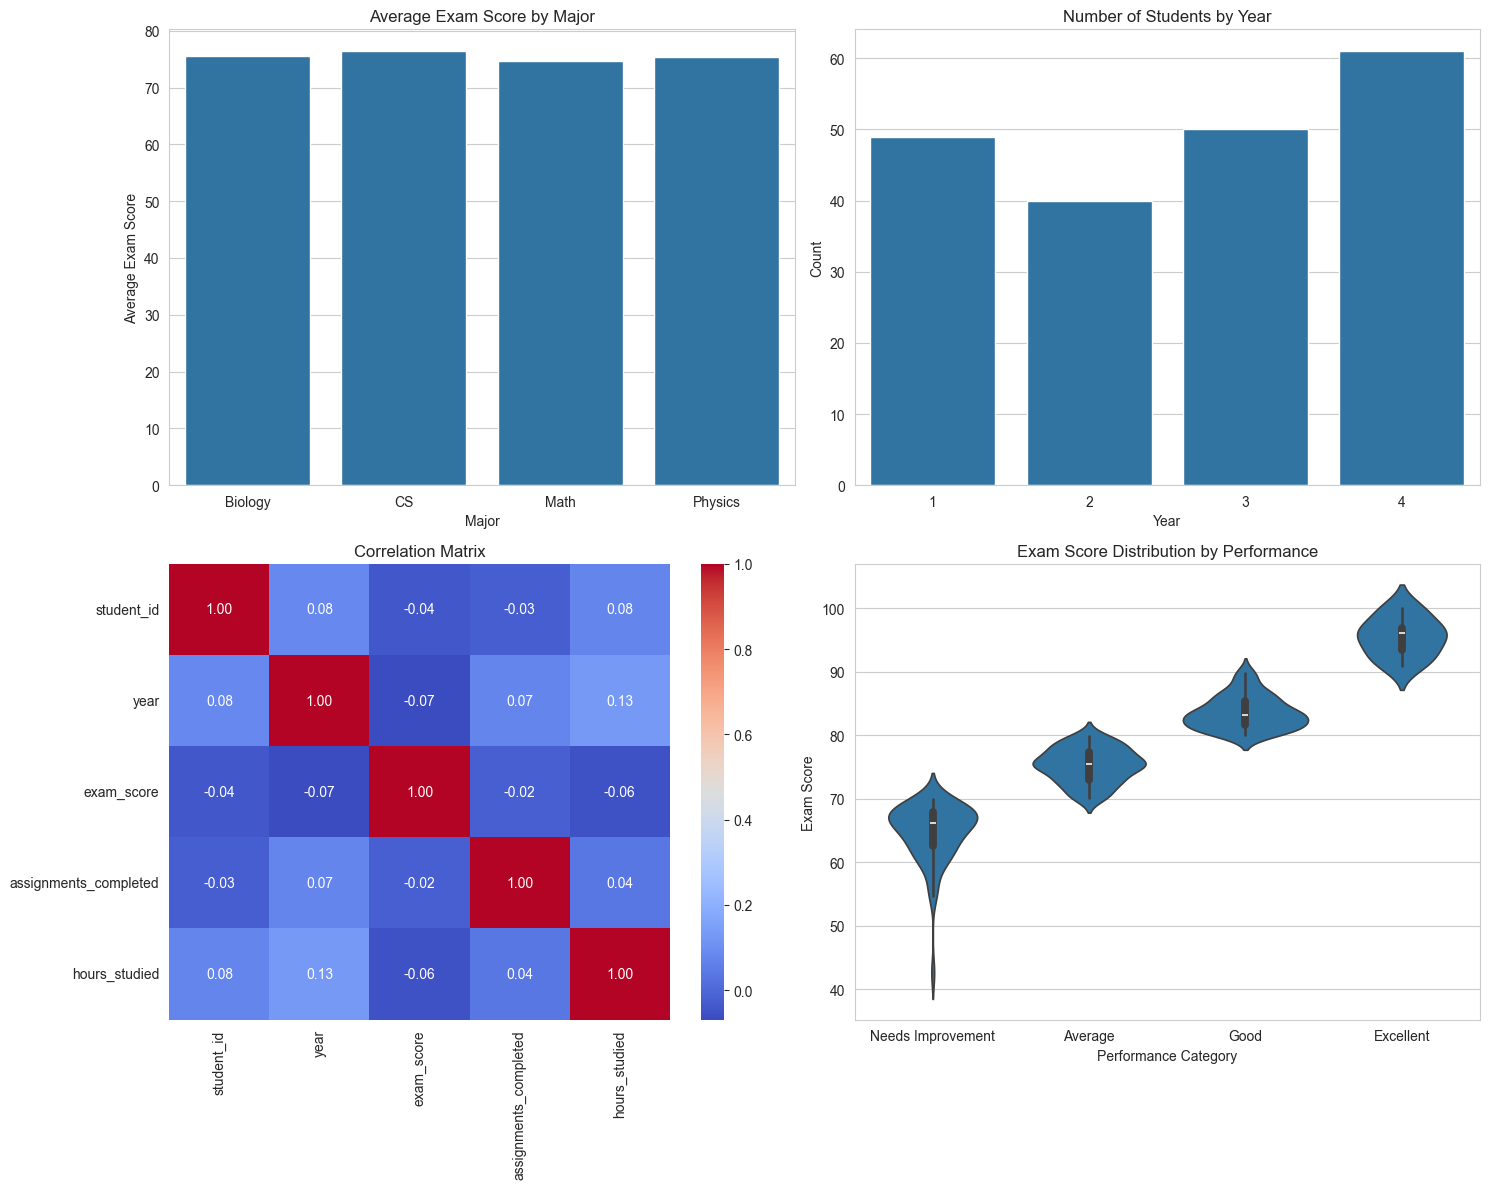

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Using the df from Exercise 5
sns.set_style("whitegrid")

# Task 1: Distribution Visualization
# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Histogram of exam scores with KDE overlay
sns.histplot(data=df, x="exam_score", kde=True, bins=10, ax=axes[0])

axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frequency")

# Right: Box plot of exam scores by major
sns.boxplot(data=df, x="major", y="exam_score", ax=axes[1])

# Add appropriate titles, labels, and styling
axes[1].set_title("Exam Scores by Major")
axes[1].set_xlabel("Major")
axes[1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization
plt.figure(figsize=(10, 6))

# Create a scatter plot of hours_studied vs exam_score
# Color points by major
sns.scatterplot(data=df, x="hours_studied", y="exam_score", hue="major", s=100)

# Add a regression line
sns.regplot(data=df, x="hours_studied", y="exam_score", scatter=False, color="black")

# Include appropriate legends, titles, and axis labels
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Major")
plt.show()

# Task 3: Advanced Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Create a 2x2 subplot figure containing:
# 1. Bar chart: Average exam score by major
avg_scores = df.groupby("major")["exam_score"].mean().reset_index()

sns.barplot(data=avg_scores, x="major", y="exam_score", ax=axes[0, 0])

axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_xlabel("Major")
axes[0, 0].set_ylabel("Average Exam Score")

# 2. Count plot: Number of students by year
sns.countplot(data=df, x="year", ax=axes[0, 1])

axes[0, 1].set_title("Number of Students by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Count")

# 3. Heat map: Correlation matrix of numerical columns
numerical_cols = df.select_dtypes(include=["number"])
corr_matrix = numerical_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 0])

axes[1, 0].set_title("Correlation Matrix")

# 4. Violin plot: Exam score distribution by performance category
sns.violinplot(data=df, x="performance", y="exam_score", ax=axes[1, 1])

axes[1, 1].set_title("Exam Score Distribution by Performance")
axes[1, 1].set_xlabel("Performance Category")
axes[1, 1].set_ylabel("Exam Score")

# Adjust layout, add titles, and ensure readability
plt.tight_layout()
plt.show()